In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [11]:
train_dir = r"C:\Users\Sanhita\Desktop\Research_2022\Data Set\Project1\CT Image\p1\Train1"
validation_dir = r"C:\Users\Sanhita\Desktop\Research_2022\Data Set\Project1\CT Image\p1\Validation1"
test_dir = r"C:\Users\Sanhita\Desktop\Research_2022\Data Set\Project1\CT Image\p1\Test1"

In [12]:
IMG_SIZE = 224

train_datagen = ImageDataGenerator(

rescale=1./255,

rotation_range=20,

zoom_range=0.20,

width_shift_range=0.20,

height_shift_range=0.20,

horizontal_flip=True

)

validation_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
train_generator = train_datagen.flow_from_directory(

train_dir,

target_size=(224,224),

batch_size=32,

class_mode='binary'

)

validation_generator = validation_datagen.flow_from_directory(

validation_dir,

target_size=(224,224),

batch_size=32,

class_mode='binary'

)

test_generator = test_datagen.flow_from_directory(

test_dir,

target_size=(224,224),

batch_size=1,

shuffle=False,

class_mode='binary'

)

Found 253 images belonging to 2 classes.
Found 90 images belonging to 2 classes.
Found 90 images belonging to 2 classes.


In [14]:
base_model = EfficientNetB0(

include_top=False,

weights='imagenet',

input_shape=(224,224,3)

)

base_model.trainable=False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256,activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(1,activation='sigmoid')(x)

model = Model(base_model.input,output)

16705208/16705208 [==============================] - 3s 0us/step


In [15]:
model.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']

)

In [16]:
earlystop = EarlyStopping(

monitor='val_loss',

patience=5,

restore_best_weights=True

)

checkpoint = ModelCheckpoint(

'best_model.keras',

save_best_only=True

)

In [18]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.12.0
Keras: 2.12.0


In [19]:
print(train_generator.samples)
print(validation_generator.samples)
print(test_generator.samples)

print(train_generator.class_indices)


253
90
90
{'Normal': 0, 'Tumor': 1}


In [20]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)
print(images.dtype)
print(labels.dtype)
print(labels[:5])


(32, 224, 224, 3)
(32,)
float32
float32
[0. 0. 1. 1. 0.]


In [21]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2
)

Epoch 1/2
8/8 [==============================] - 27s 3s/step - loss: 0.6977 - accuracy: 0.5692 - val_loss: 0.7501 - val_accuracy: 0.5000
Epoch 2/2
8/8 [==============================] - 36s 4s/step - loss: 0.7118 - accuracy: 0.5455 - val_loss: 0.7407 - val_accuracy: 0.5000


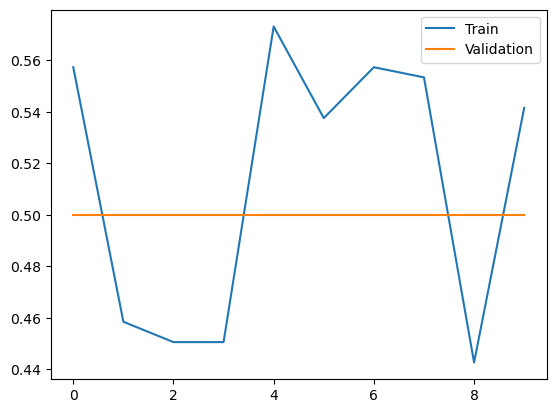

In [36]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.show()

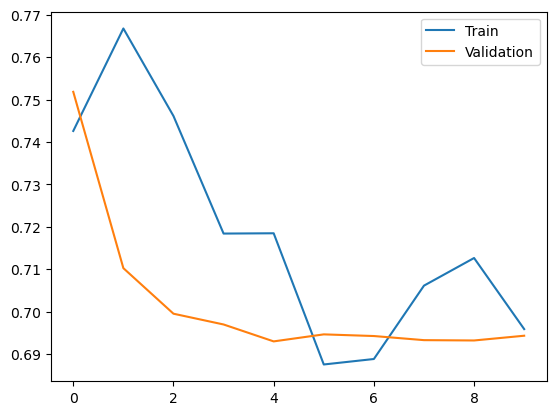

In [37]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
loss,accuracy=model.evaluate(test_generator)

print("Accuracy =",accuracy)